# Bibliotecas

In [1]:
using LinearAlgebra
using Plots
using GaussQuadrature
using SparseArrays
using Printf
using Random
using CairoMakie
using DelimitedFiles
using PrettyTables
using DataFrames
using FileIO
using ImageIO

## Seed de aleatoriedade

In [2]:
seed = 42
Random.seed!(seed)
print("Seed ", seed, " fixada para testes. Comentar linha para retormar aleatoriedade")

Seed 42 fixada para testes. Comentar linha para retormar aleatoriedade

# Base

In [3]:
function ϕ(a::Int64)::Function
    if a == 1
        return (ξ₁::Float64, ξ₂::Float64) -> (1.0-ξ₁)*(1.0-ξ₂)/4.0
        
    elseif a == 2
        return (ξ₁::Float64, ξ₂::Float64) -> (1.0+ξ₁)*(1.0-ξ₂)/4.0
        
    elseif a == 3
        return (ξ₁::Float64, ξ₂::Float64) -> (1.0+ξ₁)*(1.0+ξ₂)/4.0
        
    elseif a == 4
        return (ξ₁::Float64, ξ₂::Float64) -> (1.0-ξ₁)*(1.0+ξ₂)/4.0
        
    end
end

function ∂ϕ(a::Int64, variable::Int64)::Function
    if variable == 1
        if a == 1
            return (ξ₁::Float64, ξ₂::Float64) -> -(1.0-ξ₂)/4.0
        elseif a == 2
            return (ξ₁::Float64, ξ₂::Float64) ->  (1.0-ξ₂)/4.0
        elseif a == 3
            return (ξ₁::Float64, ξ₂::Float64) ->  (1.0+ξ₂)/4.0
        elseif a == 4
            return (ξ₁::Float64, ξ₂::Float64) -> -(1.0+ξ₂)/4.0
        end
        
    elseif variable == 2
        if a == 1
            return (ξ₁::Float64, ξ₂::Float64) -> -(1.0-ξ₁)/4.0
        elseif a == 2
            return (ξ₁::Float64, ξ₂::Float64) -> -(1.0+ξ₁)/4.0
        elseif a == 3
            return (ξ₁::Float64, ξ₂::Float64) ->  (1.0+ξ₁)/4.0
        elseif a == 4
            return (ξ₁::Float64, ξ₂::Float64) ->  (1.0-ξ₁)/4.0
        end
        
    end
end

∂ϕ (generic function with 1 method)

# Funções auxiliares

In [4]:
function plot_error_curves(h::Vector{Float64}, erros::Vector{Float64})
   plot(h, erros, lw=3, label="Erro", xscale = :log10, yscale = :log10, markershape=:circle)
   display(plot!(h, h.^2, lw=3, label="h²", xscale = :log10, yscale = :log10, legend=:topleft)) 
end

plot_error_curves (generic function with 1 method)

In [5]:
function malha2D(pt1::Vector{Float64}, pt2::Vector{Float64}, Nx1::Int64, Nx2::Int64)
    # Define o comprimento da base (h₁) e altura (h₂) de cada elemento retangular Ωᵉ
    h₁ = (pt2[1] - pt1[1]) / Nx1
    h₂ = (pt2[2] - pt1[2]) / Nx2

    # Define a discretização em x₁ e x₂
    x₁ = collect(pt1[1]:h₁:pt2[1])
    x₂ = collect(pt1[1]:h₂:pt2[2])

    # Define as coordenadas de cada nó da malha
    X₁ = [x₁[i] for i in 1:Nx1+1, j in 1:Nx2+1]
    X₂ = [x₂[j] for i in 1:Nx1+1, j in 1:Nx2+1]

    return X₁, X₂, h₁, h₂
end

malha2D (generic function with 1 method)

In [6]:
function elementCoords(element, LG, X)
    return [X[LG[:, element], 1];; X[LG[:, element], 2]]
end    

elementCoords (generic function with 1 method)

In [7]:
function malha2D_adiciona_ruido!(X₁::Matrix{Float64}, X₂::Matrix{Float64},
                                 h₁::Float64, h₂::Float64)
    # Verifica se as matrizes têm a mesma dimensão
    @assert size(X₁) == size(X₂) "X₁ e X₂ devem ter as mesmas dimensões"
    
    # Verifica se a malha é suficientemente grande para ter nós internos
    if size(X₁, 1) > 2 && size(X₁, 2) > 2
        # Define os limites do ruído
        ruído_limite₁, ruído_limite₂ = h₁ / 4, h₂ / 4
        
        # Aplica ruído uniforme aos nós internos
        X₁[2:end-1, 2:end-1] .+= ruído_limite₁ * 
                                (rand(Float64, size(X₁[2:end-1,2:end-1])) .- 0.5) * 2
        X₂[2:end-1, 2:end-1] .+= ruído_limite₂ * 
                                (rand(Float64, size(X₂[2:end-1,2:end-1])) .- 0.5) * 2
    end
end

malha2D_adiciona_ruido! (generic function with 1 method)

In [8]:
t = []::Union{Vector{Float64}, Vector{Any}}
#append!(t, 1.0)
display(t)
#typeof(t)

Any[]

# Funções de Montagem auxiliar (EQ e LG)

In [9]:
function montaEQ(Nx1::Int64, Nx2::Int64, n_dir::Int64, nos_prescritos)
    n_eqs = (Nx1+1)*(Nx2+1)
    nos_prescritos = map(unique, nos_prescritos)
    qtd_prescritos = sum([size(v)[1] for v in nos_prescritos])

    m = ((n_eqs*n_dir) - qtd_prescritos) ::Int64
    EQ = ((m+1) * ones(Int, n_eqs, n_dir)) ::Matrix{Int64} 

    index = 1
    for i in 1:n_eqs
        for dir in 1:n_dir                
            if !(i in nos_prescritos[dir])
                EQ[i, dir] = index 
                index += 1
            end
        end
    end

    return (m, EQ)
end

function getQuadSideNodes(Nx1::Int64, Nx2::Int64, side::Int64)::Vector{Union{Any, Int64}}
    nodes = []
    
    if side == 1
        nodes = reduce(vcat, 1:Nx1+1)
    end
    if side == 2
        nodes = reduce(vcat, Nx1+1:Nx1+1:(Nx2+1)*(Nx1+1))
    end
    if side == 3
        nodes = reduce(vcat, Nx2*(Nx1+1)+1:(Nx2+1)*(Nx1+1)) 
    end
    if side == 4
        nodes = reduce(vcat, 1:Nx1+1:Nx2*(Nx1+1)+1)
    end

    return nodes    
end

function getQuadSideElements(Nx1::Int64, Nx2::Int64, side::Int64)::Vector{Union{Any, Int64}}
    elements = []

    if side == 1
        elements = reduce(vcat, 1:Nx1)
    end
    if side == 2
        elements = reduce(vcat, Nx1:Nx1:(Nx2)*(Nx1))
    end
    if side == 3
        elements = reduce(vcat, Nx1*(Nx2-1)+1:1:(Nx2)*(Nx1)) 
    end
    if side == 4
        elements = reduce(vcat, 1:Nx1:Nx1*(Nx2-1)+1)
    end

    return elements  
end

function getSidefromNode(node::Int64, Nx1::Int64, Nx2::Int64)
    
    sides = []
    
    if node in 1:Nx1+1
        append!(sides, 1)
    end
        
    if node in Nx1+1:Nx1+1:(Nx2+1)*(Nx1+1)
        append!(sides, 2)
    end
    
    if node in Nx2*(Nx1+1)+1:(Nx2+1)*(Nx1+1)
        append!(sides, 3)
    end
    
    if node in 1:Nx1+1:Nx2*(Nx1+1)+1
        append!(sides, 4)
    end
    
    return sides
    
end

function getBoundariesOfElement(e::Int64, Nx1::Int64, Nx2::Int64, LG)
    boundaries = []

    for node in LG[:, e]
        append!(boundaries, getSidefromNode(node, Nx1, Nx2))
    end

    return unique(boundaries)
end

function showEQ(Nx1::Int64, Nx2::Int64, EQ)
    EQ_matrix = transpose(reshape(EQ, (Nx1+1, Nx2+1)))
    display(reverse(reverse(EQ_matrix), dims=2))
end

showEQ (generic function with 1 method)

In [10]:
function montaLG(Nx1::Int64, Nx2::Int64)::Matrix{Int64}
    vec_line = (line::Int64) -> (Nx1+1)*line .+ (1:Nx1)
    vec = vec_line.(0:Nx2-1)
    
    get_LG_column = (corner_index::Int64) -> [corner_index; corner_index + 1;
                                              corner_index + Nx1+2; corner_index + Nx1+1]
    
    flat_matrix = Iterators.flatten(map(x -> get_LG_column.(x), vec))
    matrix = reshape(collect(Iterators.flatten(flat_matrix)), (4, Nx1*Nx2))
    
    return matrix
end

montaLG (generic function with 1 method)

# Visualizador

In [11]:
function getQuad(x, y, LG, elem)
    
    idx00 = LG[elem, 1]    
    idx01 = LG[elem, 2]    
    idx11 = LG[elem, 3]    
    idx10 = LG[elem, 4]
    
    X = [x[idx00], x[idx10], x[idx11], x[idx01]]
    Y = [y[idx00], y[idx10], y[idx11], y[idx01]]
    
    return X, Y
end

function drawQuadInFig(fig, xVertices, yVertices)
    for i in 1:3
        xPair = [xVertices[i], xVertices[i+1]]
        yPair = [yVertices[i], yVertices[i+1]]
        linesegments!(fig[1,1], xPair, yPair, color=:navy)
    end
    
    xPair = [xVertices[4], xVertices[1]]
    yPair = [yVertices[4], yVertices[1]]
    linesegments!(fig[1,1], xPair, yPair, color=:navy)
    
    return fig
end

function drawGrid(xValues, yValues, numX, numY, LG, windowX, windowY)
    LGᵗ = transpose(LG)
    
    f = Figure(size=(500, 500))
    Axis(f[1, 1], limits=(0, windowX, 0, windowY))
    
    for i in 1:numY
        for j in 1:numX
            
            elem = (i-1)*(numX) + j
            
            xVertices, yVertices = getQuad(xValues, yValues, LGᵗ, elem)
            drawQuadInFig(f, xVertices, yVertices)
        end
    end
    
    return f
end

function drawGridFromFile(elemX, elemY, coordsFileName, LGFileName, xWindowLim, yWindowLim)
    malhaFile = readdlm(coordsFileName)

    X, Y = malhaFile[:, 2], malhaFile[:, 3]

    LG = readdlm(LGFileName)[:, 1:4]
    LG = convert(Matrix{Int}, LG) 
    LG = LG .+ 1 # Indices 1-based (julia)
    
    return drawGrid(X, Y, elemX, elemY, transpose(LG), xWindowLim, yWindowLim)
end

drawGridFromFile (generic function with 1 method)

# Caso quadrilátero convexo com lados não-paralelos

In [12]:
function simpleDet(M)
    return (M[1, 1] * M[2, 2]) - (M[1, 2] * M[2, 1])
end

function simpleInv(M)
    det_M = abs(simpleDet(M))
    inv_M = 1/det_M * [ M[2, 2] -M[1, 2]
                       -M[2, 1]  M[1, 1]]
    return inv_M
end

function calcL(s1::Float64, s2::Float64, β::Float64, B, inv_B)
    L = zeros(2,2,2,2) 
    delta = 1.0I
    
    for i in 1:2
        for j in 1:2
            for k in 1:2
                for l in 1:2
                    L[i, j, k, l] = β*delta[k, l]*delta[i, j] + s1*(delta[i, k]*B[l, j] + B[i, l]*delta[j, k]) -
                                    s2*(inv_B[i, k] * delta[l, j] + delta[l, i]*inv_B[k, j])
                end
            end
        end
    end
    
    return L
end

calcL (generic function with 1 method)

In [13]:
function ξ_to_x(Xᵉ_a, ξ₁::Float64, ξ₂::Float64)::Float64
    ϕ_ξ = map(func -> func(ξ₁, ξ₂), ϕ.(1:length(Xᵉ_a)))
    # print("Xe_a = ", Xᵉ_a, "\n")
    # print("ϕ_ξ = ", ϕ_ξ, "\n")
    
    return Xᵉ_a ⋅ ϕ_ξ
end

function ∂ξ_to_∂x(Xᵉ_a, variable::Int64, ξ₁::Float64, ξ₂::Float64)::Float64
    dϕ_dξ = map(func -> func(ξ₁, ξ₂), ∂ϕ.(1:length(Xᵉ_a), variable))
    #print("Xe_a = ", Xᵉ_a, "\n")
    #print("dϕ_dξ = ", dϕ_dξ, "\n")
    
    return Xᵉ_a ⋅ dϕ_dξ
end

∂ξ_to_∂x (generic function with 1 method)

In [14]:
function mapper_to_x_generic(Xᵉ_a::Vector{Float64})::Function
    return (ξ₁::Float64, ξ₂::Float64)-> Xᵉ_a ⋅ map(f -> f(ξ₁, ξ₂), ϕ.(1:length(Xᵉ_a)))
end

mapper_to_x_generic (generic function with 1 method)

In [15]:
function joinToPoints(X₁, X₂)
    # line index = point, columns = coordinate
    points = hcat(reshape(X₁, (:, 1)), reshape(X₂, (:, 1)))
    
    return points    
end

# Viraram a mesma coisa ^ v

function build_X(X₁, X₂)
   return [reshape(X₁, (:, 1));; reshape(X₂, (:, 1))]
end

build_X (generic function with 1 method)

In [16]:
function build_g(nodes, coords, values)::Function
    nodes_coords = coords[nodes, :]
    
    g = function(x) 
            if(x in nodes_coords)
                return values[findfirst(item -> item == x, nodes_coords)]
            else
                return [0.0; 0.0]
            end
        end
    
    return g    
end

build_g (generic function with 1 method)

In [17]:
function bound_expr(num_fronteira, nos_fronteira, e_fronteira, X, P, LG)
    coords_nos_front = []
    
    for no in nos_fronteira
        append!(coords_nos_front, [X[no, :]])
    end

    for e in e_fronteira
        Xᵉ = elementCoords(e, LG, X)
        ξ_to_x1 = mapper_to_x_generic(Xᵉ[:, 1])
        ξ_to_x2 = mapper_to_x_generic(Xᵉ[:, 2])
        
        if(num_fronteira == 1)
            for ξ in P
                x1_ξ1 = ξ_to_x1(ξ, -1.0)
                x2_ξ2 = ξ_to_x2(ξ, -1.0)  
                append!(coords_nos_front, [[x1_ξ1, x2_ξ2]])
            end
        end

        if(num_fronteira == 2)
            for ξ in P
                x1_ξ1 = ξ_to_x1(1.0, ξ)
                x2_ξ2 = ξ_to_x2(1.0, ξ)
                append!(coords_nos_front, [[x1_ξ1, x2_ξ2]])
            end
        end

        if(num_fronteira == 3)
            for ξ in P
                x1_ξ1 = ξ_to_x1(ξ, 1.0)
                x2_ξ2 = ξ_to_x2(ξ, 1.0)
                append!(coords_nos_front, [[x1_ξ1, x2_ξ2]])
            end
        end

        if(num_fronteira == 4)
            for ξ in P
                x1_ξ1 = ξ_to_x1(-1.0, ξ)
                x2_ξ2 = ξ_to_x2(-1.0, ξ)
                append!(coords_nos_front, [[x1_ξ1, x2_ξ2]])
            end
        end
    end

    #println(coords_nos_front)
    
    expr =  function(coords_no)
                if(coords_no in coords_nos_front)
                    return true
                else
                    return false
                end
            end
    
    return expr
end

bound_expr (generic function with 1 method)

In [18]:
# p1 = [0.0, 0.0]
# p2 = [4.0, 0.0]
# p3 = [8.0, 4.0]
# p4 = [4.0, 4.0]

# bound1 = bound_expr(p1, p2, p1, p3)
# bound2 = bound_expr(p2, p3, p1, p3)
# bound3 = bound_expr(p4, p3, p1, p3)
# bound4 = bound_expr(p1, p4, p1, p3)

In [19]:
# tests = [
#             p1,
#             p2,
#             p3,
#             p4,
#             [1.0, 0.0],
#             [6.0, 2.0],
#             [6.0, 4.0],
#             [1.0, 1.0],
#             [0.5, 0.5],
#             [-1.0, -1.0],
#             [2.0, -2.0],
#             [9.0, 5.0],
#             [-2.0, 2.0],
#             [-1.0, 0.5],
#             [2.0, 0.5],
#             [0.5, 2.0],
#             [-1.0, 0.5]
#         ]

# for pt_test in tests
#     println("Caso: ", pt_test)
#     println("Bound 1 = ", bound1(pt_test))
#     println("Bound 2 = ", bound2(pt_test))
#     println("Bound 3 = ", bound3(pt_test))
#     println("Bound 4 = ", bound4(pt_test))
# end




In [20]:
function build_f(pontos_fronteira::Array, nos_fronteira, e_fronteira, X, P, LG, τ::Float64)  
    p1 = pontos_fronteira[1]
    p2 = pontos_fronteira[2]
    p3 = pontos_fronteira[3]
    p4 = pontos_fronteira[4]
    
    dy = p4[2] - p1[2]
    dx = p4[1] - p1[1]
    dl = sqrt(dx^2 + dy^2)
    _sen = dy/dl
    _cos = dx/dl

    bound1 = bound_expr(1, nos_fronteira[1], e_fronteira[1], X, P, LG)
    bound2 = bound_expr(2, nos_fronteira[2], e_fronteira[2], X, P, LG)
    bound3 = bound_expr(3, nos_fronteira[3], e_fronteira[3], X, P, LG)
    bound4 = bound_expr(4, nos_fronteira[4], e_fronteira[4], X, P, LG)
    
    f = function(ponto)
            tracao = zeros(2) 
            #println("Checking for ", ponto)
        
            if(bound1(ponto))
                tracao[1] += -τ
                tracao[2] += 0.0
            end
        
            if(bound2(ponto))
                tracao[1] += τ * _cos
                tracao[2] += τ * _sen
            end
        
            if(bound3(ponto))
                tracao[1] += τ
                tracao[2] += 0.0
            end
        
            if(bound4(ponto))
                tracao[1] += -τ * _cos
                tracao[2] += -τ * _sen
            end
        
            return tracao
        end
    
    return f 
end

build_f (generic function with 1 method)

## Quadraturas

In [21]:
function quadratura_K_local(a::Int64, b::Int64, params::Array{Float64}, indexes, Xᵉ, F_defᵉ, Tᵉ, P::Vector{Float64}, W::Vector{Float64})::Float64
    
    quadratura = 0.0
    s1, s2, p, β = params
    r, s = indexes    
    
    soma1 = 0.0
    soma2 = 0.0
    soma3 = 0.0
    
    n_pts = size(P)[1]
    for iter1 in 1:n_pts
        for iter2 in 1:n_pts
            
            ξ₁, w₁ = P[iter1], W[iter1]
            ξ₂, w₂ = P[iter2], W[iter2]
            
            dx_dξ = [∂ξ_to_∂x(Xᵉ[:, 1], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 1], 2, ξ₁, ξ₂)
                     ∂ξ_to_∂x(Xᵉ[:, 2], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 2], 2, ξ₁, ξ₂)]

            det_J_ξ = abs(simpleDet(dx_dξ))
            dξ_dx = simpleInv(dx_dξ)

            F = F_defᵉ
            B = F * transpose(F)
            inv_B = simpleInv(B)

            #display(B)
            #display(inv_B)
            
            L = calcL(s1, s2, β, B, inv_B)
            
            termo1 = 0.0
            termo2 = 0.0
            termo3 = 0.0
            
            for i in 1:2
                for k in 1:2
                    for l in 1:2
                        termo1 += Tᵉ[r, i] * ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, i] * ∂ϕ(b, l)(ξ₁, ξ₂) * dξ_dx[l, s] * det_J_ξ
                        termo2 += Tᵉ[r, i] * ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, s] * ∂ϕ(b, l)(ξ₁, ξ₂) * dξ_dx[l, i] * det_J_ξ
                        
                        for j in 1:2
                            termo3 += L[r, i, s, j] * ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, i] * ∂ϕ(b, l)(ξ₁, ξ₂) * dξ_dx[l, j] * det_J_ξ
                        end
                    end
                end
            end
            
            soma1 += termo1
            soma2 += termo2
            soma3 += termo3
            
            quadratura += (w₁ * w₂) * (termo1 - termo2 + termo3)
        end
    end
    
#     println("Soma 1: ", soma1)
#     println("Soma 2: ", soma2)
#     println("Soma 3: ", soma3)
    
    return quadratura
end

quadratura_K_local (generic function with 1 method)

In [22]:
function quadratura_F_local(f::Function, g::Function, presc_map, a::Int64, indexes, boundaries, Xᵉ, Kᵉ::Matrix{Float64}, F_defᵉ, Tᵉ, P::Vector{Float64}, W::Vector{Float64})
    quadratura = 0.0
    r = indexes

    ξ_to_x1 = mapper_to_x_generic(Xᵉ[:, 1])
    ξ_to_x2 = mapper_to_x_generic(Xᵉ[:, 2])
    
    if(length(boundaries) != 0)        
        for b in 1:4
            ponto = (Xᵉ[b, 1], Xᵉ[b, 2])
            #display(f(ponto))
            
            for (ξ, w) in zip(P, W)                
                termo1 = 0.0
                
                # Integral lado 1
                p1 = Xᵉ[1, :]
                p2 = Xᵉ[2, :]

                x1_ξ1 = ξ_to_x1(ξ, -1.0)
                x2_ξ2 = ξ_to_x2(ξ, -1.0)
                
                tamanho_lado = sqrt((p2[1] - p1[1])^2 + (p2[2] - p1[2])^2)
                termo1 += w * ϕ(a)(ξ, -1.0) * ϕ(b)(ξ, -1.0) * f([x1_ξ1, x2_ξ2])[r] * tamanho_lado/2
                                                                           # fator 2 = tamanho do lado 
                                                                           # do elemento padrão
                #println("f1: ", f([x1_ξ1, x2_ξ2])[r])
                # Integral lado 2
                p1 = Xᵉ[2, :]
                p2 = Xᵉ[3, :]

                x1_ξ1 = ξ_to_x1(1.0, ξ)
                x2_ξ2 = ξ_to_x2(1.0, ξ)

                tamanho_lado = sqrt((p2[1] - p1[1])^2 + (p2[2] - p1[2])^2)
                termo1 += w * ϕ(a)(1.0, ξ) * ϕ(b)(1.0, ξ) * f([x1_ξ1, x2_ξ2])[r] * tamanho_lado/2

                #println("f2: ", f([x1_ξ1, x2_ξ2])[r])
                # Integral lado 3
                p1 = Xᵉ[3, :]
                p2 = Xᵉ[4, :]

                x1_ξ1 = ξ_to_x1(ξ, 1.0)
                x2_ξ2 = ξ_to_x2(ξ, 1.0)

                tamanho_lado = sqrt((p2[1] - p1[1])^2 + (p2[2] - p1[2])^2)
                termo1 += w * ϕ(a)(ξ, 1.0) * ϕ(b)(ξ, 1.0) * f([x1_ξ1, x2_ξ2])[r] * tamanho_lado/2

                #println("f3: ", f([x1_ξ1, x2_ξ2])[r])
                # Integral lado 4
                p1 = Xᵉ[1, :]
                p2 = Xᵉ[4, :]

                x1_ξ1 = ξ_to_x1(-1.0, ξ)
                x2_ξ2 = ξ_to_x2(-1.0, ξ)

                tamanho_lado = sqrt((p2[1] - p1[1])^2 + (p2[2] - p1[2])^2)
                termo1 += w * ϕ(a)(-1.0, ξ) * ϕ(b)(-1.0, ξ) * f([x1_ξ1, x2_ξ2])[r] * tamanho_lado/2

                #println("f4: ", f([x1_ξ1, x2_ξ2])[r])
                quadratura += termo1   
                #println("quad = ", quadratura, " a = ", a, " b = ", b)
            end        
        end
    end
    
    #println("Quadratura até parcela 1")
    #display(quadratura)    

    # montar só parcela 2 pra debug
    #quadratura = 0.0
    
    prescrito = presc_map[r][a]
    
    if(!prescrito)
        n_pts = size(P)[1]
        for i in 1:2
            soma = 0.0
            somaP = 0.0
            for iter1 in 1:n_pts
                for iter2 in 1:n_pts                
                    ξ₁, w₁ = P[iter1], W[iter1]
                    ξ₂, w₂ = P[iter2], W[iter2]
                    
                    dx_dξ = [∂ξ_to_∂x(Xᵉ[:, 1], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 1], 2, ξ₁, ξ₂)
                             ∂ξ_to_∂x(Xᵉ[:, 2], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 2], 2, ξ₁, ξ₂)]
    
                    #display(dx_dξ)
                    det_J_ξ = abs(simpleDet(dx_dξ))
                    dξ_dx = simpleInv(dx_dξ)
    
                    termo2 = 0.0
                    for k in 1:2            
                        termo2 += (w₁ * w₂) * Tᵉ[r,i] * ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, i] * det_J_ξ    
                        # println("P; k = ", k, ": ", ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, i] * det_J_ξ)
                        # println("dPhi = ", ∂ϕ(a, k)(ξ₁, ξ₂))
                        # println("dξ_dx = ", dξ_dx[k, i])
                        # println("det_J_ξ = ", det_J_ξ)
                        # println("")
                        somaP += ∂ϕ(a, k)(ξ₁, ξ₂) * dξ_dx[k, i] * det_J_ξ
                    end
                    soma += termo2
                    quadratura -= termo2
                end
            end
            # println("Tᵉ = ", Tᵉ[r,i])
            # println("P = ", somaP)        
            # println("quad a = ", a, " r = ", r, " i = ", i, ": ", soma)
            # println("check: ", soma/Tᵉ[r,i])
            # println("=======================================")
        end
    end
    

    #println("Quadratura até a parcela 2")
    #display(quadratura)

    
    for b in 1:4        
        ponto = (Xᵉ[b, 1], Xᵉ[b, 2])
        
        termo3 = 0.0
        termo3 += Kᵉ[a, b] * g(ponto)[r]
        
        quadratura -= termo3
    end
     #println("Quadratura até parcela 3 (final)")
     #display(quadratura)
    
    return quadratura
end

quadratura_F_local (generic function with 1 method)

## Funções de Montagem local (K e F)

In [23]:
function monta_K_local(params::Array{Float64}, Xᵉ, F_defᵉ, Tᵉ, P::Vector{Float64}, W::Vector{Float64})::Matrix{Float64}    
    Kᵉ = zeros(8, 8)

    for a in 1:4
        for r in 1:2
            for b in 1:4            
                for s in 1:2
                    m, n = (2*(a-1) + r, 2*(b-1) + s)                    
                    
                    indexes = [r, s]
                    #println("a, b = ", a, b, "\n Indexes (r, s, i, j) = ", indexes)
                    Kᵉ[m, n] += quadratura_K_local(a, b, params, indexes, Xᵉ, F_defᵉ, Tᵉ, P, W)
                end
            end
        end
    end
    
    return Kᵉ
end

monta_K_local (generic function with 1 method)

In [24]:
function monta_F_local(f::Function, g, presc_map, boundaries, Xᵉ, Kᵉ, F_defᵉ, Tᵉ, P::Vector{Float64}, W::Vector{Float64})::Vector{Float64}
    F_local = zeros(8)
    
    for a in 1:4
        for r in 1:2
            m = 2*(a-1) + r
            
            indexes = r
            F_local[m] += quadratura_F_local(f, g, presc_map, a, indexes, boundaries, Xᵉ, Kᵉ, F_defᵉ, Tᵉ, P, W)
            #indexes = r
            #println("a = ", a, " r = ", r, " m = ", m)
            #F_local[m] += quadratura_F_local(f, g, a, indexes, boundaries, Xᵉ, Kᵉ, F_defᵉ, Tᵉ, P, W)
            #println("")
            #println("Fᵉ[", m, "] = ", F_local[m])
            #println("")
        end
    end
    
    return F_local    
end

monta_F_local (generic function with 1 method)

## Dados

In [25]:
# winX = 2.0
# winY = 2.0

# λ₁ = 1.0
# λ₂ = 1.0

# ponto_inf_esq = [0.0; 0.0]
# ponto_inf_dir = [λ₁ ; 0.0]
# ponto_sup_dir = [λ₁ ; λ₂ ]
# ponto_sup_esq = [0.0; λ₂ ]

# Nx1 = 20
# Nx2 = 20

# LG = montaLG(Nx1, Nx2)
# display(LG)

# X₁, X₂, h₁, h₂ = malha2D(ponto_inf_esq, ponto_sup_dir, Nx1, Nx2)
# println("Done")
# #drawGrid(X₁, X₂, Nx1, Nx2, LG, winX, winY)

In [26]:
# getSidefromNode(16, 3, 3)

In [27]:
# n_dir = 2

# fronteiras = [
# getQuadSideNodes(Nx1, Nx2, 1), 
# getQuadSideNodes(Nx1, Nx2, 2), 
# getQuadSideNodes(Nx1, Nx2, 3),
# getQuadSideNodes(Nx1, Nx2, 4)
# ]

# presc_x1 = [1]
# presc_x2 = fronteiras[1]
# presc = [presc_x1, presc_x2]

# m, EQ = montaEQ(Nx1, Nx2, n_dir, presc)

# #print("m = ", m)
# #showEQ(Nx1, Nx2, EQ[:, 1])
# #showEQ(Nx1, Nx2, EQ[:, 2])

In [28]:
# n = 1
# Δt = 1.0
# τ = n * Δt
# pts_fronteira = [ponto_inf_esq, ponto_inf_dir, ponto_sup_dir, ponto_sup_esq]

# f = build_f(pts_fronteira, τ)

In [29]:
# display(f([0.0; 0.0]))
# display(f([1.0; 0.0]))
# display(f([1.0; 1.0]))
# display(f([0.0; 1.0]))

# display(f([0.5; 0.0]))
# display(f([1.0; 0.5]))
# display(f([0.5; 1.0]))
# display(f([0.0; 0.5]))

In [30]:
# coords = joinToPoints(X₁, X₂)
# #display(coords)

# nodes = unique(Iterators.flatten(presc))
# #display(nodes)


# values = repeat([[0.0; 0.0]], size(nodes)[1])

# g = build_g(nodes, coords, values)

In [31]:
# display(g([0/3; 0.0]))
# display(g([1/3; 0.0]))
# display(g([2/3; 0.0]))
# display(g([3/3; 0.0]))

# display(g([1/3; 1/3]))

## Testes de Montagem

In [32]:
# X = build_X(X₁, X₂)
# #display(X)

In [33]:
# # s1, s2, p, β 
# s1 =  1.0
# s2 = -0.1
# β  = 10.0^4

# h  = -s2/s1
# # Atualizações de p??
# p = 1-h

# params = [s1, s2, p, β]

In [34]:
# T₀_e = Matrix(0.0I, 2, 2)
# F₀_e = repeat([Matrix(1.0I, 2, 2)], 2, 2)

In [35]:
# P, W = legendre(2)

# e = 1
# e_boundaries = getBoundariesOfElement(e, Nx1, Nx2, LG)
# display(e_boundaries)

# Xᵉ = elementCoords(e, LG, X)
# F_defᵉ = copy(F₀_e )
# Tᵉ = copy(T₀_e)

# Kᵉ = monta_K_local(params, Xᵉ, F_defᵉ, Tᵉ, P, W)
# display(Kᵉ)

# Fᵉ = monta_F_local(f, g, e_boundaries, Xᵉ, Kᵉ, F_defᵉ, Tᵉ, P, W)
# display(Fᵉ)

In [36]:
# display(Xᵉ)

# display(e_boundaries)

In [37]:
# # Campo atualizado no tempo 1 de a cordo com o código do Gabriel

# coordsFileName = "malhaPasso-1-2020.out"
# LGFileName = "LG-2020.out"

# drawGridFromFile(Nx1, Nx2, coordsFileName, LGFileName, winX, winY)

In [38]:
function dirichlet_map(presc, e, LG)
    ndir = size(presc)[1]
    map = (zeros(Bool, 4), zeros(Bool, 4))
    for dir in 1:ndir
        for pt in 1:4
            if(LG[pt, e] in presc[dir])
                map[dir][pt] = true
            end
        end
    end

    return map
end

dirichlet_map (generic function with 1 method)

## Funções de Montagem global (K e F)

In [39]:
function monta_K_F_global(params::Array{Float64}, f::Function, pts_fronteira, g::Function, presc, Nx1, Nx2, X::AbstractMatrix{Float64}, F_def, T, m::Int64, EQ::Matrix{Int64}, LG::Matrix{Int64})
    K_global = spzeros(m+1, m+1)
    F_global = zeros(m+1)
    EQ_X1_LG = EQ[:, 1][LG]
    EQ_X2_LG = EQ[:, 2][LG]
    
    P, W = legendre(2)
    ne = size(LG)[2]
    
    for e in 1:ne
        #println("e = ", e)
        e_boundaries = getBoundariesOfElement(e, Nx1, Nx2, LG)
        
        Xᵉ = elementCoords(e, LG, X)
        
        F_defᵉ = F_def[e]
        Tᵉ = T[e]
        
        Kᵉ = monta_K_local(params, Xᵉ, F_defᵉ, Tᵉ, P, W)

        presc_map = dirichlet_map(presc, e, LG)        
        Fᵉ = monta_F_local(f, g, presc_map, e_boundaries, Xᵉ, Kᵉ, F_defᵉ, Tᵉ, P, W)
        #display(Fᵉ)
        #println("\n", "Elemento ", e, "\n")
        for a in 1:4
            for r in 1:2
                index_i = EQ[:, r][LG][a, e]
                for b in 1:4
                    for s in 1:2
                        index_j = EQ[:, s][LG][b, e]
                        #println("[", index_i, ", ", index_j, "] com ", "a = ", a, ", r = ", r, " b = ", b, ", s = ", s)
                        K_global[index_i, index_j] += Kᵉ[2*(a-1)+r, 2*(b-1)+s]
                    end
                end
                F_global[index_i] += Fᵉ[2*(a-1)+r]
                #println("F[", index_i, "] = ", F_global[index_i])
            end
        end
    end
    
    return (K_global[1:m, 1:m], F_global[1:m])
end

monta_K_F_global (generic function with 1 method)

In [40]:
# display(EQ[:, 1][LG[:, 2]])
# display(EQ[:, 2][LG[:, 2]])

# display(EQ)

### Testes de Montagem

In [41]:
# ne = Nx1 * Nx2
# F_def = repeat([F₀_e], ne)
# T = repeat([Matrix(0.0I, 2, 2)], ne)

In [42]:
# K, F = monta_K_F_global(params, f, pts_fronteira, g, Nx1, Nx2, X, F_def, T, m, EQ, LG)

In [43]:
# print(F)

In [44]:
function print_nz(A)
    for col in 1:size(A, 2)
        for r in nzrange(A, col)
            println(rowvals(A)[r], ' ', col, ' ',  nonzeros(A)[r])
        end
    end
end

print_nz (generic function with 1 method)

In [45]:
# _vec = [-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.025, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, -0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.025, -0.025, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.05, 0.0, 0.025, 0.025]

### Solução

In [46]:
# c = K\F

In [47]:
# c2 = K\_vec

In [48]:
# c3 = [-1.19607e-12, -2.47149e-12, -3.80195e-12, -5.17179e-12, -6.56943e-12, -7.98513e-12, -9.41239e-12, -1.0846e-11, -1.22841e-11, -1.37263e-11, -1.5171e-11, -1.66199e-11, -1.80749e-11, -1.95386e-11, -2.10174e-11, -2.25179e-11, -2.40479e-11, -2.56171e-11, -2.72374e-11, -2.89292e-11, 0.0454545, 1.07273e-12, 0.0454545, 1.16882e-12, 0.0454545, 1.23733e-12, 0.0454545, 1.28658e-12, 0.0454545, 1.32407e-12, 0.0454545, 1.35039e-12, 0.0454545, 1.36835e-12, 0.0454545, 1.38172e-12, 0.0454545, 1.38908e-12, 0.0454545, 1.39859e-12, 0.0454545, 1.40533e-12, 0.0454545, 1.41137e-12, 0.0454545, 1.42135e-12, 0.0454545, 1.43115e-12, 0.0454545, 1.44638e-12, 0.0454545, 1.46868e-12, 0.0454545, 1.49704e-12, 0.0454545, 1.53469e-12, 0.0454545, 1.58207e-12, 0.0454545, 1.64328e-12, 0.0454545, 1.72967e-12, 0.0909091, 2.02052e-12, 0.0909091, 2.20898e-12, 0.0909091, 2.34932e-12, 0.0909091, 2.45292e-12, 0.0909091, 2.53393e-12, 0.0909091, 2.59307e-12, 0.0909091, 2.6357e-12, 0.0909091, 2.66932e-12, 0.0909091, 2.69095e-12, 0.0909091, 2.71692e-12, 0.0909091, 2.7373e-12, 0.0909091, 2.75618e-12, 0.0909091, 2.78287e-12, 0.0909091, 2.80913e-12, 0.0909091, 2.8459e-12, 0.0909091, 2.89652e-12, 0.0909091, 2.95892e-12, 0.0909091, 3.0393e-12, 0.0909091, 3.13818e-12, 0.0909091, 3.26324e-12, 0.0909091, 3.43311e-12, 0.136364, 2.87304e-12, 0.136364, 3.14742e-12, 0.136364, 3.35837e-12, 0.136364, 3.51837e-12, 0.136364, 3.64627e-12, 0.136364, 3.74225e-12, 0.136364, 3.81414e-12, 0.136364, 3.87309e-12, 0.136364, 3.91415e-12, 0.136364, 3.96196e-12, 0.136364, 4.00129e-12, 0.136364, 4.03839e-12, 0.136364, 4.08723e-12, 0.136364, 4.13521e-12, 0.136364, 4.19854e-12, 0.136364, 4.28169e-12, 0.136364, 4.38161e-12, 0.136364, 4.50743e-12, 0.136364, 4.65914e-12, 0.136364, 4.84702e-12, 0.136364, 5.09533e-12, 0.181818, 3.65179e-12, 0.181818, 4.00544e-12, 0.181818, 4.28379e-12, 0.181818, 4.49995e-12, 0.181818, 4.67649e-12, 0.181818, 4.81156e-12, 0.181818, 4.91572e-12, 0.181818, 5.0034e-12, 0.181818, 5.06757e-12, 0.181818, 5.14117e-12, 0.181818, 5.20385e-12, 0.181818, 5.2634e-12, 0.181818, 5.33853e-12, 0.181818, 5.41196e-12, 0.181818, 5.50487e-12, 0.181818, 5.62313e-12, 0.181818, 5.76227e-12, 0.181818, 5.93421e-12, 0.181818, 6.13811e-12, 0.181818, 6.38596e-12, 0.181818, 6.70695e-12, 0.227273, 4.37345e-12, 0.227273, 4.79992e-12, 0.227273, 5.14183e-12, 0.227273, 5.41233e-12, 0.227273, 5.63724e-12, 0.227273, 5.81296e-12, 0.227273, 5.9512e-12, 0.227273, 6.06966e-12, 0.227273, 6.15922e-12, 0.227273, 6.26148e-12, 0.227273, 6.35074e-12, 0.227273, 6.43614e-12, 0.227273, 6.54083e-12, 0.227273, 6.64192e-12, 0.227273, 6.76565e-12, 0.227273, 6.92017e-12, 0.227273, 7.099e-12, 0.227273, 7.31632e-12, 0.227273, 7.57018e-12, 0.227273, 7.87405e-12, 0.227273, 8.26177e-12, 0.272727, 5.0517e-12, 0.272727, 5.54422e-12, 0.272727, 5.9447e-12, 0.272727, 6.26633e-12, 0.272727, 6.53782e-12, 0.272727, 6.7541e-12, 0.272727, 6.92706e-12, 0.272727, 7.07728e-12, 0.272727, 7.19364e-12, 0.272727, 7.3268e-12, 0.272727, 7.44492e-12, 0.272727, 7.55812e-12, 0.272727, 7.69443e-12, 0.272727, 7.82477e-12, 0.272727, 7.97994e-12, 0.272727, 8.17104e-12, 0.272727, 8.38902e-12, 0.272727, 8.65036e-12, 0.272727, 8.95168e-12, 0.272727, 9.30747e-12, 0.272727, 9.75603e-12, 0.318182, 5.69753e-12, 0.318182, 6.24885e-12, 0.318182, 6.70239e-12, 0.318182, 7.07097e-12, 0.318182, 7.38642e-12, 0.318182, 7.64159e-12, 0.318182, 7.8489e-12, 0.318182, 8.03109e-12, 0.318182, 8.17551e-12, 0.318182, 8.34049e-12, 0.318182, 8.48873e-12, 0.318182, 8.63121e-12, 0.318182, 8.80033e-12, 0.318182, 8.9601e-12, 0.318182, 9.14704e-12, 0.318182, 9.37488e-12, 0.318182, 9.63143e-12, 0.318182, 9.93496e-12, 0.318182, 1.02807e-11, 0.318182, 1.06842e-11, 0.318182, 1.11877e-11, 0.363636, 6.32018e-12, 0.363636, 6.92295e-12, 0.363636, 7.42427e-12, 0.363636, 7.83589e-12, 0.363636, 8.1924e-12, 0.363636, 8.48446e-12, 0.363636, 8.72434e-12, 0.363636, 8.9385e-12, 0.363636, 9.11152e-12, 0.363636, 9.30885e-12, 0.363636, 9.48719e-12, 0.363636, 9.65937e-12, 0.363636, 9.86083e-12, 0.363636, 1.00495e-11, 0.363636, 1.02679e-11, 0.363636, 1.0532e-11, 0.363636, 1.08263e-11, 0.363636, 1.11693e-11, 0.363636, 1.15564e-11, 0.363636, 1.20031e-11, 0.363636, 1.25561e-11, 0.409091, 6.92747e-12, 0.409091, 7.57606e-12, 0.409091, 8.11938e-12, 0.409091, 8.56939e-12, 0.409091, 8.96305e-12, 0.409091, 9.28915e-12, 0.409091, 9.55943e-12, 0.409091, 9.80467e-12, 0.409091, 1.00061e-11, 0.409091, 1.02365e-11, 0.409091, 1.04458e-11, 0.409091, 1.06476e-11, 0.409091, 1.08811e-11, 0.409091, 1.10986e-11, 0.409091, 1.13477e-11, 0.409091, 1.16456e-11, 0.409091, 1.19741e-11, 0.409091, 1.23536e-11, 0.409091, 1.27782e-11, 0.409091, 1.32635e-11, 0.409091, 1.38604e-11, 0.454545, 7.52764e-12, 0.454545, 8.21671e-12, 0.454545, 8.79694e-12, 0.454545, 9.27931e-12, 0.454545, 9.70448e-12, 0.454545, 1.00611e-11, 0.454545, 1.03599e-11, 0.454545, 1.0636e-11, 0.454545, 1.08658e-11, 0.454545, 1.1129e-11, 0.454545, 1.13684e-11, 0.454545, 1.15994e-11, 0.454545, 1.18644e-11, 0.454545, 1.21111e-11, 0.454545, 1.23903e-11, 0.454545, 1.27191e-11, 0.454545, 1.30787e-11, 0.454545, 1.34914e-11, 0.454545, 1.39484e-11, 0.454545, 1.44661e-11, 0.454545, 1.51013e-11, 0.5, 8.12783e-12, 0.5, 8.85169e-12, 0.5, 9.46273e-12, 0.5, 9.97164e-12, 0.5, 1.04236e-11, 0.5, 1.08067e-11, 0.5, 1.11329e-11, 0.5, 1.1438e-11, 0.5, 1.16958e-11, 0.5, 1.199e-11, 0.5, 1.22577e-11, 0.5, 1.25158e-11, 0.5, 1.28099e-11, 0.5, 1.30851e-11, 0.5, 1.33938e-11, 0.5, 1.37525e-11, 0.5, 1.41408e-11, 0.5, 1.4583e-11, 0.5, 1.50678e-11, 0.5, 1.56123e-11, 0.5, 1.62809e-11, 0.545455, 8.73332e-12, 0.545455, 9.48573e-12, 0.545455, 1.0121e-11, 0.545455, 1.06514e-11, 0.545455, 1.1127e-11, 0.545455, 1.15343e-11, 0.545455, 1.1885e-11, 0.545455, 1.22155e-11, 0.545455, 1.24978e-11, 0.545455, 1.28203e-11, 0.545455, 1.31143e-11, 0.545455, 1.33972e-11, 0.545455, 1.37174e-11, 0.545455, 1.40193e-11, 0.545455, 1.43557e-11, 0.545455, 1.47427e-11, 0.545455, 1.51573e-11, 0.545455, 1.56262e-11, 0.545455, 1.61352e-11, 0.545455, 1.67027e-11, 0.545455, 1.73994e-11, 0.590909, 9.34814e-12, 0.590909, 1.01218e-11, 0.590909, 1.07755e-11, 0.590909, 1.13235e-11, 0.590909, 1.18203e-11, 0.590909, 1.22503e-11, 0.590909, 1.26227e-11, 0.590909, 1.2974e-11, 0.590909, 1.32768e-11, 0.590909, 1.3623e-11, 0.590909, 1.39395e-11, 0.590909, 1.42436e-11, 0.590909, 1.45868e-11, 0.590909, 1.49136e-11, 0.590909, 1.52757e-11, 0.590909, 1.56894e-11, 0.590909, 1.61286e-11, 0.590909, 1.66221e-11, 0.590909, 1.71526e-11, 0.590909, 1.77396e-11, 0.590909, 1.84598e-11, 0.636364, 9.97564e-12, 0.636364, 1.07644e-11, 0.636364, 1.1431e-11, 0.636364, 1.19934e-11, 0.636364, 1.25096e-11, 0.636364, 1.29591e-11, 0.636364, 1.33507e-11, 0.636364, 1.37211e-11, 0.636364, 1.40422e-11, 0.636364, 1.44079e-11, 0.636364, 1.47419e-11, 0.636364, 1.50627e-11, 0.636364, 1.54259e-11, 0.636364, 1.57757e-11, 0.636364, 1.61615e-11, 0.636364, 1.66e-11, 0.636364, 1.70616e-11, 0.636364, 1.75771e-11, 0.636364, 1.81259e-11, 0.636364, 1.8729e-11, 0.636364, 1.94669e-11, 0.681818, 1.06163e-11, 0.681818, 1.14171e-11, 0.681818, 1.20941e-11, 0.681818, 1.26679e-11, 0.681818, 1.32001e-11, 0.681818, 1.36658e-11, 0.681818, 1.40735e-11, 0.681818, 1.4459e-11, 0.681818, 1.47965e-11, 0.681818, 1.51804e-11, 0.681818, 1.55289e-11, 0.681818, 1.58627e-11, 0.681818, 1.62423e-11, 0.681818, 1.66106e-11, 0.681818, 1.70173e-11, 0.681818, 1.7479e-11, 0.681818, 1.79613e-11, 0.681818, 1.84964e-11, 0.681818, 1.90614e-11, 0.681818, 1.96775e-11, 0.681818, 2.04279e-11, 0.727273, 1.12703e-11, 0.727273, 1.20798e-11, 0.727273, 1.27655e-11, 0.727273, 1.33482e-11, 0.727273, 1.38949e-11, 0.727273, 1.4373e-11, 0.727273, 1.47923e-11, 0.727273, 1.51905e-11, 0.727273, 1.55409e-11, 0.727273, 1.59409e-11, 0.727273, 1.63031e-11, 0.727273, 1.66485e-11, 0.727273, 1.70407e-11, 0.727273, 1.74235e-11, 0.727273, 1.78472e-11, 0.727273, 1.8331e-11, 0.727273, 1.8833e-11, 0.727273, 1.9386e-11, 0.727273, 1.99645e-11, 0.727273, 2.05909e-11, 0.727273, 2.13503e-11, 0.772727, 1.19363e-11, 0.772727, 1.27513e-11, 0.772727, 1.34425e-11, 0.772727, 1.40332e-11, 0.772727, 1.45939e-11, 0.772727, 1.50821e-11, 0.772727, 1.55102e-11, 0.772727, 1.59179e-11, 0.772727, 1.62802e-11, 0.772727, 1.66943e-11, 0.772727, 1.70681e-11, 0.772727, 1.74246e-11, 0.772727, 1.78284e-11, 0.772727, 1.82237e-11, 0.772727, 1.86628e-11, 0.772727, 1.91654e-11, 0.772727, 1.96852e-11, 0.772727, 2.02542e-11, 0.772727, 2.08427e-11, 0.772727, 2.14769e-11, 0.772727, 2.22419e-11, 0.818182, 1.26127e-11, 0.818182, 1.34315e-11, 0.818182, 1.41265e-11, 0.818182, 1.47231e-11, 0.818182, 1.52949e-11, 0.818182, 1.57913e-11, 0.818182, 1.62278e-11, 0.818182, 1.66449e-11, 0.818182, 1.70177e-11, 0.818182, 1.74452e-11, 0.818182, 1.78314e-11, 0.818182, 1.81985e-11, 0.818182, 1.86122e-11, 0.818182, 1.9018e-11, 0.818182, 1.94696e-11, 0.818182, 1.99871e-11, 0.818182, 2.05209e-11, 0.818182, 2.11037e-11, 0.818182, 2.17019e-11, 0.818182, 2.23429e-11, 0.818182, 2.31117e-11, 0.863636, 1.32951e-11, 0.863636, 1.4118e-11, 0.863636, 1.4817e-11, 0.863636, 1.54179e-11, 0.863636, 1.59978e-11, 0.863636, 1.65015e-11, 0.863636, 1.69477e-11, 0.863636, 1.73756e-11, 0.863636, 1.776e-11, 0.863636, 1.8201e-11, 0.863636, 1.86007e-11, 0.863636, 1.8978e-11, 0.863636, 1.93993e-11, 0.863636, 1.98144e-11, 0.863636, 2.02752e-11, 0.863636, 2.08047e-11, 0.863636, 2.13489e-11, 0.863636, 2.19419e-11, 0.863636, 2.2549e-11, 0.863636, 2.31962e-11, 0.863636, 2.39668e-11, 0.909091, 1.39801e-11, 0.909091, 1.48053e-11, 0.909091, 1.55089e-11, 0.909091, 1.61148e-11, 0.909091, 1.67016e-11, 0.909091, 1.72123e-11, 0.909091, 1.76676e-11, 0.909091, 1.81079e-11, 0.909091, 1.85049e-11, 0.909091, 1.89599e-11, 0.909091, 1.93728e-11, 0.909091, 1.97596e-11, 0.909091, 2.01889e-11, 0.909091, 2.06129e-11, 0.909091, 2.10824e-11, 0.909091, 2.1621e-11, 0.909091, 2.21753e-11, 0.909091, 2.27767e-11, 0.909091, 2.33911e-11, 0.909091, 2.40436e-11, 0.909091, 2.48154e-11]

In [49]:
function soma_solução(X, solução, npts, m, EQ)
    X_novo = copy(X)
    for pt in 1:npts
        for dir in 1:2
            idx = EQ[pt, dir]
            if idx != m+1
                X_novo[pt, dir] += solução[idx]
            end   
        end
    end
    
    return X_novo
end

soma_solução (generic function with 1 method)

In [50]:
# npts = (Nx1 + 1) * (Nx2 + 1)

# X_novo = soma_solução(X, c, npts, m, EQ)
# X_novo2 = soma_solução(X, c2, npts, m, EQ)
# X_novo3 = soma_solução(X, c3, npts, m, EQ)

# println("Done")
# #display(EQ)

In [51]:
# display(X)
# display(X_novo)
# display(X_novo2)
# display(X_novo3)

In [52]:
# display(drawGrid(X_novo[:, 1], X_novo[:, 2], Nx1, Nx2, LG, winX, winY))
# display(drawGrid(X_novo2[:, 1], X_novo2[:, 2], Nx1, Nx2, LG, winX, winY))
# display(drawGrid(X_novo3[:, 1], X_novo3[:, 2], Nx1, Nx2, LG, winX, winY))

In [53]:
function calc_F_def_0(X, ne, LG)
    F_def_0 = []
    
    ξ₁ = 0.0
    ξ₂ = 0.0
    for e in 1:ne
        Xᵉ = elementCoords(e, LG, X)
        F_defᵉ = [∂ξ_to_∂x(Xᵉ[:, 1], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 1], 2, ξ₁, ξ₂)
                  ∂ξ_to_∂x(Xᵉ[:, 2], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Xᵉ[:, 2], 2, ξ₁, ξ₂)]
        
        
        
        append!(F_def_0, [F_defᵉ])
    end
    
    return F_def_0
end

calc_F_def_0 (generic function with 1 method)

In [54]:
function grad_u(Δu, X, F_def_0, ne, LG)
    
    H = []
    
    for e in 1:ne
        Δuᵉ = elementCoords(e, LG, Δu)
        Xᵉ = elementCoords(e, LG, X)
        
        ξ₁ = 0.0
        ξ₂ = 0.0
        
        # reutilizando a função ∂ξ_to_∂x, mas idealmente o nome seria ∂ξ_to_∂u... ou "interpolate <something>"
        du_dξ = [∂ξ_to_∂x(Δuᵉ[:, 1], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Δuᵉ[:, 1], 2, ξ₁, ξ₂)
                 ∂ξ_to_∂x(Δuᵉ[:, 2], 1, ξ₁, ξ₂) ∂ξ_to_∂x(Δuᵉ[:, 2], 2, ξ₁, ξ₂)]
        
        dx_dξ = F_def_0[e]

        #display("du_dξ = ")
        #display(du_dξ)
        det_J_ξ = abs(simpleDet(dx_dξ))
        dξ_dx = simpleInv(dx_dξ)

        Hᵉ = du_dξ * dξ_dx
        
        append!(H, [Hᵉ])
        #display(H[e])
    end
    
    return H
end

grad_u (generic function with 1 method)

In [55]:
# ne = length(F_def)
# Δu = X_novo - X
# F_def_0 = calc_F_def_0(X_novo, ne, LG)

# test = grad_u(Δu, X, F_def_0, ne, LG)

In [56]:
# F_def_ini = repeat([Matrix(1.0I, 2, 2)], ne)

In [57]:
function atualiza_ALI(X_inicial, X_novo, F_def, T, ne, LG)
    F_t_mais_1 = []
    T_t_mais_1 = []
    
    Δu = X_novo - X_inicial
    
    F_def_0 = calc_F_def_0(X_inicial, ne, LG)
    H = grad_u(Δu, X_inicial, F_def_0, ne, LG)
    
    for e in 1:ne
        F = F_def[e]
        
        det_J_ξ = abs(simpleDet(F))        
        dξ_dx = simpleInv(F)

        Hᵉ = H[e]
        B = F * transpose(F)
        inv_B = simpleInv(B)

        L = calcL(s1, s2, β, B, inv_B)
        Tᵉ = copy(T[e])
        
        for i in 1:2
            for j in 1:2
                soma = 0.0
                for k in 1:2
                    for l in 1:2
                        Tᵉ[i, j] += L[i, j, k, l] * Hᵉ[k, l] 
                    end
                end                
            end
        end
        
        # pressão
        #P_0 -= β * tr(H)
        
        Fᵉ_t_mais_1 = (1.0I + Hᵉ) * F
        
        #display(Fᵉ_t_mais_1)
        #display(Tᵉ)
        
        append!(F_t_mais_1, [Fᵉ_t_mais_1])
        append!(T_t_mais_1, [Tᵉ])        
    end
    
    return F_t_mais_1, T_t_mais_1
end

atualiza_ALI (generic function with 1 method)

In [58]:
# novo_F, novo_T = atualiza_ALI(X, X_novo, F_def_ini, T, ne, LG)

In [59]:
# novo_F

In [60]:
# novo_T

In [61]:
function calcula_erro(passo, F_def, s1, s2, τ, pts_fronteira, ne)
    max_F11 = 0.0
    min_F11 = 2.0
    sum_F11 = 0.0
    sum_det = 0.0
    
    for F in F_def
        sum_det += simpleDet(F)
        sum_F11 += F[1,1]
        max_F11 = (F[1,1] > max_F11) ? F[1,1] : max_F11
        min_F11 = (F[1,1] < min_F11) ? F[1,1] : min_F11
    end

    λ₁_analitico = (1.0 - τ^2*(1.0/(s1 - s2)^2))^(-1.0/4)
    k = sqrt(λ₁_analitico^4 - 1.0)

    p1 = pts_fronteira[1]
    p2 = pts_fronteira[2]
    p4 = pts_fronteira[4]

    OA_num = p2[1] - p1[1]
    OB_num = sqrt((p4[1]^2 - p1[1]^2) + (p4[2]^2 - p1[2]^2))

    OA_analitico = λ₁_analitico^2
    #F_11 médio
    λ₁_numerico = sum_F11/ne
    det_medio = sum_det/ne

    erro_relativo_percentual = 100*abs((λ₁_numerico - λ₁_analitico)/λ₁_analitico)
    razao_segmentos = 100*abs((OA_num - OB_num)/OA_num)
    infos_principais = [passo, 
                        λ₁_analitico, 
                        λ₁_numerico, 
                        min_F11, 
                        max_F11, 
                        det_medio, 
                        erro_relativo_percentual, 
                        razao_segmentos]::Vector{Float64}
    
    infos_secundarias = [k, OA_analitico]

    return infos_principais, infos_secundarias    
end

calcula_erro (generic function with 1 method)

In [62]:
function write_results(infos_primarias, infos_secundarias, u_vec, Δτ, Nx1, Nx2)
    n_passos = length(infos_primarias)
    main_filename = @sprintf("resultados_delta-%f_nPassos-%i_malha%ix%i.txt", Δτ, n_passos, Nx1, Nx2)
    u_filename = @sprintf("soulcao_delta-%f_nPassos-%i_malha%ix%i.txt", Δτ, n_passos, Nx1, Nx2)
    alt_filename = @sprintf("optional_delta-%f_nPassos-%i_malha%ix%i.txt", Δτ, n_passos, Nx1, Nx2)

    open(main_filename, "w") do io
        writedlm(io, infos_primarias)
    end
    println("Informações principais salvas em ", main_filename)

    open(u_filename, "w") do io
        writedlm(io, u_vec)
    end
    println("Soluções u salvas em ", u_filename)

    open(alt_filename, "w") do io
        writedlm(io, infos_secundarias)
    end
    println("Informações adicionais salvas em ", alt_filename)
    
    return
end

write_results (generic function with 1 method)

In [63]:
typeof([0.0; 0.0])

Vector{Float64} (alias for Array{Float64, 1})

In [64]:
function iterador_principal(λ₁::Float64, 
                            λ₂::Float64, 
                            Nx1::Int64, 
                            Nx2::Int64, 
                            params::Vector{Float64}, 
                            Δτ::Float64, 
                            n_passos::Int64)
    
    winX = 2.0 #typed
    winY = 2.0 #typed

    ponto_inf_esq = [0.0; 0.0] #typed
    ponto_inf_dir = [λ₁ ; 0.0] #typed
    ponto_sup_dir = [λ₁ ; λ₂ ] #typed
    ponto_sup_esq = [0.0; λ₂ ] #typed

    LG = montaLG(Nx1, Nx2) #typed

    X₁, X₂, h₁, h₂ = malha2D(ponto_inf_esq, ponto_sup_dir, Nx1, Nx2) #typed
    X = build_X(X₁, X₂) #typed (Matrix{Float64})
    
    #display(X₁) #typed (Matrix{Float64})
    #display(X₂) #typed (Matrix{Float64})
    
    n_dir = 2 #typed

    fronteiras = [
        getQuadSideNodes(Nx1, Nx2, 1), 
        getQuadSideNodes(Nx1, Nx2, 2), 
        getQuadSideNodes(Nx1, Nx2, 3),
        getQuadSideNodes(Nx1, Nx2, 4)
    ]
    
    #display(fronteiras)

    presc_x1 = [1]
    presc_x2 = fronteiras[1]
    presc = [presc_x1, presc_x2]

    m, EQ = montaEQ(Nx1, Nx2, n_dir, presc)
    
    pts_fronteira = [ponto_inf_esq, ponto_inf_dir, ponto_sup_dir, ponto_sup_esq]
    
    e_fronteiras = [
        getQuadSideElements(Nx1, Nx2, 1),
        getQuadSideElements(Nx1, Nx2, 2),
        getQuadSideElements(Nx1, Nx2, 3),
        getQuadSideElements(Nx1, Nx2, 4),
    ]

    P, W = legendre(2)
    τ = 1 * Δτ
    f = build_f(pts_fronteira, fronteiras, e_fronteiras, X, P, LG, τ) 
    
    coords = joinToPoints(X₁, X₂)
    nodes = (unique(Iterators.flatten(presc)))
    values = repeat([[0.0; 0.0]], size(nodes)[1])
    
    g = build_g(nodes, coords, values)    
    
    s1, s2, β =  params
    h  = -s2/s1
    # Atualizações de p?? Tr(H) ≈ 0 sempre, pode ficar de fora
    p = 1-h
    params = [s1, s2, p, β]
    
    ne = Nx1 * Nx2
    npts = (Nx1 + 1) * (Nx2 + 1)
    
    # F e T iniciais: Identidade e Matriz nula
    F_def = repeat([Matrix(1.0I, 2, 2)], ne)
    T = repeat([Matrix(0.0I, 2, 2)], ne)
    
    X_novo = []
    #K_vec = []
    #F_vec = []
    sol_vec = []
    infos_primarias = []
    infos_secundarias = []
    for iter in 1:n_passos
        
        K, F = monta_K_F_global(params, f, pts_fronteira, g, presc, Nx1, Nx2, X, F_def, T, m, EQ, LG)
        c = K\F
        
        # u em t+1
        X_novo = soma_solução(X, c, npts, m, EQ)
        #display(drawGrid(X_novo[:, 1], X_novo[:, 2], Nx1, Nx2, LG, winX, winY))
        
        novo_F, novo_T = atualiza_ALI(X, X_novo, F_def, T, ne, LG)
        
        F_def = copy(novo_F)
        T = copy(novo_T)
        X = copy(X_novo)
        append!(sol_vec, [X])

        infos1, infos2 = calcula_erro(iter, F_def, s1, s2, τ, pts_fronteira, ne)
        append!(infos_primarias, [infos1])
        append!(infos_secundarias, [infos2])

        # Fim do passo atual, prepara pra novo passo
        pts_fronteira = [X[first(fronteiras[1]), :], 
                         X[last(fronteiras[1]), :], 
                         X[last(fronteiras[3]), :], 
                         X[first(fronteiras[3]), :]]::Vector{Vector{Float64}}
        
        τ = Δτ * (iter + 1)
        f = build_f(pts_fronteira, fronteiras, e_fronteiras, X, P, LG, τ)  #function(x) return [0.0, 0.0] end
    end
    
    return sol_vec, infos_primarias, infos_secundarias
end

iterador_principal (generic function with 1 method)

In [65]:
λ₁ = 1.0
λ₂ = 1.0

Nx1 = 20
Nx2 = 20

n_passos = 8
Δτ = 0.5/n_passos


s1 =  1.0
s2 = -0.1
β  = 10.0^4
params = [s1, s2, β]

u_vec, infos_primarias, infos_secundarias = iterador_principal(λ₁, λ₂, Nx1, Nx2, params, Δτ, n_passos)
println("Done")

Done


In [66]:
write_results(infos_primarias, infos_secundarias, u_vec, Δτ, Nx1, Nx2)

Informações principais salvas em resultados_delta-0.062500_nPassos-8_malha20x20.txt
Soluções u salvas em soulcao_delta-0.062500_nPassos-8_malha20x20.txt
Informações adicionais salvas em optional_delta-0.062500_nPassos-8_malha20x20.txt


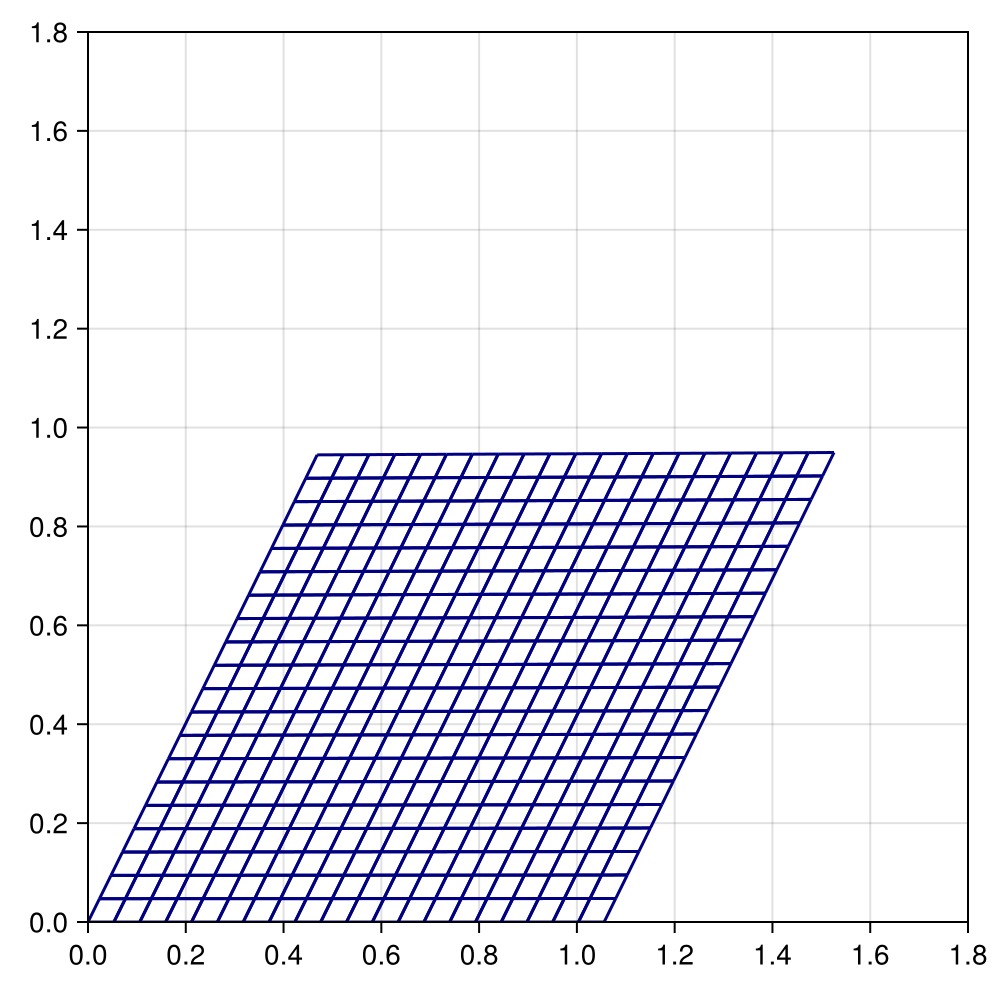

CairoMakie.Screen{IMAGE}


In [67]:
LG = montaLG(Nx1, Nx2)
u = last(u_vec)
display(drawGrid(u[:, 1], u[:, 2], Nx1, Nx2, LG, 1.8, 1.8))

In [ ]:
function display_EQs(Nx1, Nx2, EQ)
    str = ""
    for pt in size(EQ)[1]:-1:1

        str = join([@sprintf("(%03i, %03i)", EQ[pt, 1], EQ[pt, 2]), str], " ")
        if(pt in fronteiras[4])
            println(str)
            str = ""
        end
        
    end
end

In [ ]:
function show_error(infos_primarias, Δτ, Nx1, Nx2)
    steps_vec = []
    errors_vec = []
    
    for info in infos_primarias
        append!(steps_vec, info[1])
        append!(errors_vec, info[7])
    end
    
    title_str = @sprintf("Δτ = %.2e; Passos = %i; Malha %ix%i", Δτ, length(infos_primarias), Nx1, Nx2)
    display(Plots.plot( steps_vec, 
                        errors_vec, 
                        seriestype=:scatter, 
                        title=title_str,
                        label = "Erro",
                        xlabel = "Número do passo", 
                        ylabel="Erro relativo %", 
                        ms=2.0,
                        markerstrokewidth = 0.5,
                        gridlinewidth=2,
                        gridalpha=0.4,
                        dpi = 400))
    
    return
end

In [ ]:
function read_data(τ, Δτ, Nx1, Nx2)
    file_path = @sprintf("./experimentos_TCC/malha %ix%i/delta %g nPassos %i/resultados_delta-%f_nPassos-%i_malha%ix%i.txt",
                        Nx1,
                        Nx2,
                        Δτ,
                        τ/Δτ,
                        Δτ,
                        τ/Δτ,
                        Nx1,
                        Nx2
                        )
    return readdlm(file_path, '\t')
end

In [ ]:
function read_sol(τ, Δτ, Nx1, Nx2)
    file_path = @sprintf("./experimentos_TCC/malha %ix%i/delta %g nPassos %i/soulcao_delta-%f_nPassos-%i_malha%ix%i.txt",
                        Nx1,
                        Nx2,
                        Δτ,
                        τ/Δτ,
                        Δτ,
                        τ/Δτ,
                        Nx1,
                        Nx2
                        )
    return readdlm(file_path, '\t')
end

In [ ]:
function show_multiple_errors(multiple_steps_vec, multiple_errors_vec, delta_vec, Nx1, Nx2)
    curve_count = length(delta_vec)

    title_str = @sprintf("Variações de erro para Malha %ix%i", Nx1, Nx2)
    Plots.plot(title = title_str, xlabel = "Tensão de cisalhamento τ (Δτ*passo)", ylabel="Erro relativo %", dpi=400)
    
    for i in 1:curve_count
        steps_vec = multiple_steps_vec[i]
        error_vec = multiple_errors_vec[i]
        label_str = @sprintf("Δτ = %f", delta_vec[i])
        
        Plots.plot!(steps_vec, 
                    error_vec, 
                    seriestype=:scatter, 
                    yscale=:log10,
                    label=label_str,
                    legend_position=:bottomright,
                    ms=3.0,
                    markerstrokewidth = 0.5,
                    minorgrid=true,
                    gridlinewidth=2,
                    gridalpha=0.4
                    )
    end

    display(Plots.plot!())
end

In [ ]:
τ = 0.5

In [ ]:
Nx1 = 10
Nx2 = 10

delta_vec = [τ/2^(1), τ/2^(3), τ/2^(5), τ/2^(7), τ/2^(9)]
multiple_errors_vec = []
multiple_load_vec = []

for delta in delta_vec
    error_vec = read_data(τ, delta, Nx1, Nx2)[:, 7]
    steps_vec = read_data(τ, delta, Nx1, Nx2)[:, 1]
    load_vec = delta.*steps_vec
    append!(multiple_errors_vec, [error_vec])
    append!(multiple_load_vec, [load_vec])
end

show_multiple_errors(multiple_load_vec, multiple_errors_vec, delta_vec, Nx1, Nx2)

In [ ]:
Nx1 = 20
Nx2 = 20

τ = 0.56
n_passos = 140
Δτ = τ/n_passos

matrix_data = read_data(τ, Δτ, Nx1, Nx2)
infos_primarias = []

for line in 1:size(matrix_data)[1]
    append!(infos_primarias, [matrix_data[line, :]])
end

show_error(infos_primarias, Δτ, Nx1, Nx2)

In [ ]:
winX = 1.8
winY = 1.8

λ₁ = 1.0
λ₂ = 1.0

Nx1 = 20
Nx2 = 20

ponto_inf_esq = [0.0; 0.0]
ponto_inf_dir = [λ₁ ; 0.0]
ponto_sup_dir = [λ₁ ; λ₂ ]
ponto_sup_esq = [0.0; λ₂ ]

LG = montaLG(Nx1, Nx2)

X₁, X₂, h₁, h₂ = malha2D(ponto_inf_esq, ponto_sup_dir, Nx1, Nx2)
X = build_X(X₁, X₂)

τ = 0.56
n_passos = 140
Δτ = τ/n_passos

matrix_data = read_sol(τ, Δτ, Nx1, Nx2)
passos_de_carga = 1:n_passos
solucoes = []
push!(solucoes, X)

for passo in passos_de_carga
    coords_x1 = matrix_data[passo, 1:(Nx1+1)*(Nx2+1)]
    coords_x2 = matrix_data[passo, ((Nx1+1)*(Nx2+1))+1:2*((Nx1+1)*(Nx2+1))]
    solucao = hcat(coords_x1, coords_x2)
    append!(solucoes, [solucao])
end

In [ ]:
# pesado em memória, talvez necessário fazer por partes
for i in 1:length(solucoes)
    u = solucoes[i]
    figure = drawGrid(u[:, 1], u[:, 2], Nx1, Nx2, LG, winX, winY)
    img_str = @sprintf("gif_images/fig_%i.png", i) 
    save(img_str, figure)
end

In [ ]:
images = []
for i in 1:length(solucoes)-1
    img_str = @sprintf("gif_images/fig_%i.png", i)
    push!(images, load(img_str))
end
    
save("animation_10fps.gif", cat(images..., dims=3); fps=10)